This notebook aims to debug my current ccsa custom implementation and check wheter my adaptation can make it more parameter-independent. We will first focus on diminishing the potential differences with the NLOPT implementation, then provide possible alternatives for the adaptation of parameters like the trust region, the curvature, w, parameter for the control of the curvature update. Finally we will understand how stochasticity affects this and how we can change the acceptance criterion to be suitable for stochastic optimization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nlopt
import torch

## Unconstrained Stochastic Convex Optimization:

Let's try the stochastic optimization problem
$$
\min_{x \in \mathbb{R}^n} E[f(x,\xi)]
$$
where
$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2
$$
and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$

The expectation value $E[\cdots]$ is for $\xi$ drawn from i.i.d. Gaussian random variables $\xi_k \sim N(0,\sigma^2)$.

Analytically, the minimizer should simply be at $x = 0$ while the minimum is $ \sigma^2 \mathrm{tr}(A^2)$.

Note that $\nabla_x f = 2A(x + \xi)$.

Our starting guess will simply be `x = randn(n)`, and we'll use $A = I$ to start with.

[82.50106044914597]


/Users/antoniovaragnolo/Desktop/Research/CCSA/experiments.py:61: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(vals, "g-", label="adam", color="green") # loglog to be done


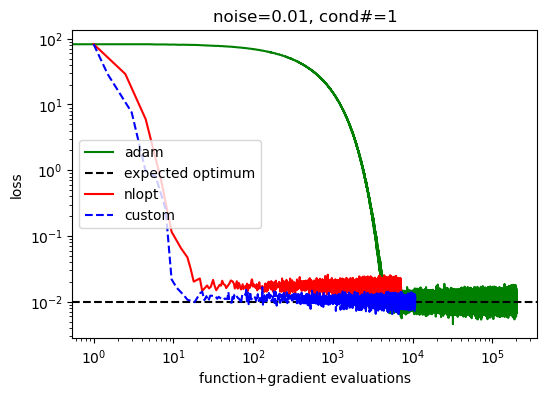

/Users/antoniovaragnolo/Desktop/Research/CCSA/ccsa_w_adaptation.py:851: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax3.scatter(i, f_hist[i], color=color, edgecolor='k', s=70, marker=marker, zorder=10)


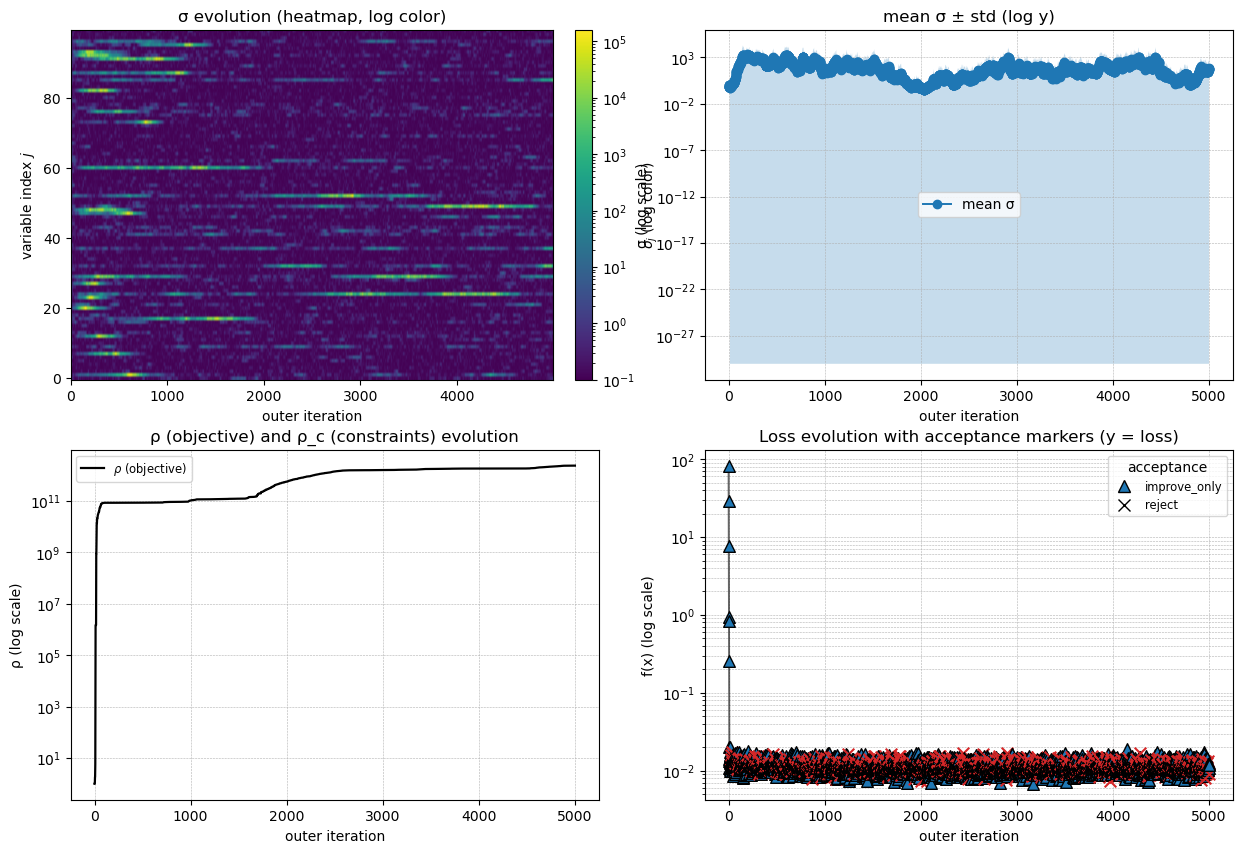

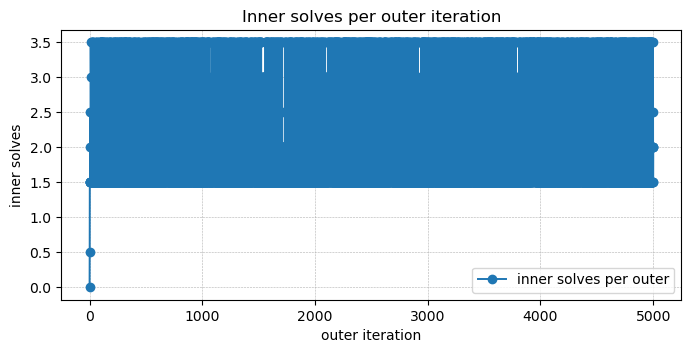


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 5001
Sigma: final mean = 4.255e+01, final std = 2.455e+02
Rho (objective): final = 2.299e+12

Acceptance counts:
Counter({'improve_only': 4137, 'reject': 863})

Average inner solves per outer step (observed): 2.15


In [2]:
from experiments import stoch_convex_unc_exp
from ccsa_w_adaptation import MMAOptimizer, MMA_SigmaParams, MMA_RhoParams
import nlopt

# deterministic RNG for the experiment
n = 100
seed = 42
sigma_min = 1e-1
rng = np.random.RandomState(seed)
x_init = rng.randn(n)

# Initialize Customer Optimizer
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=1.0)
sigma_params = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min,  rel_min=0.01, rel_max=10.0)

optimizer = MMAOptimizer(
            params=[torch.tensor(x_init, dtype=torch.float32, requires_grad=False)],
            fun=None,   
            g=None,
            x0 = x_init,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            rho_params=rho_params,
            sigma_params=sigma_params,
            df=None,      
            dg=None
        )

# Initialize Nlopt Optimizer
opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.01]:
    for cond in [1]:
        stoch_convex_unc_exp(optimizer, opt, noise=noise, cond=cond, outer = 5000, rng=rng, x_init=x_init)




## CONVEX STOCHASTIC OBJECTIVE DETERMINISTIC LINEAR CONSTRAINT

Let's define our first constrained optimization algorithm. We will start with a simple case in which we just take the above and modify with a simple linear constraint. 

$$
\min_{x \in \mathbb{R}^n} \; \mathbb{E}[f(x,\xi)] \quad \quad s.t. \quad c^T x - b \leq 0
$$

where  

$$
f(x,\xi) = \Vert A(x + \xi) \Vert_2^2, 
$$  

and $A = A^T$ is an $n \times n$ real-symmetric matrix, while $\xi \in \mathbb{R}^n$ is a random vector with $\mathbb{E}[\xi]=0$ and $\mathrm{Cov}(\xi) = \sigma_\xi^2 I$. We will divide it into 2 cases:

1.  Active Constraint (i.e. unconstrained solution is NOT in the feasible region). In this case the solution lies on the feasibility boundary and can be analytically computed by forming the lagrangian starting from the expected valued function (ignoring for the moment the noise related term)

$$
\mathcal{L}(x,\lambda) = x^T A^2 x + \lambda (c^T x - b).
$$

The KKT condition gives us

$$
\nabla_x \mathcal{L} = 2 A^2 x + \lambda c = 0 
\quad \Longrightarrow \quad 
x = -\frac{\lambda}{2} (A^2)^{-1} c.
$$

Impose the constraint \(c^T x = b\):

$$
c^T \Big(-\frac{\lambda}{2} (A^2)^{-1} c \Big) = b
\quad \Longrightarrow \quad
\lambda = -\frac{2b}{c^T (A^2)^{-1} c}.
$$

Hence the constrained optimizer is

$$
x^\ast_{\text{constr}} 
= \frac{b}{c^T (A^2)^{-1} c} \, (A^2)^{-1} c.
$$


To obtain the optimum we plug into the objective:

$$
F(x^\ast_{\text{constr}})
= (x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$

The quadratic term evaluates to

$$
(x^\ast_{\text{constr}})^T A^2 x^\ast_{\text{constr}}
= \frac{b^2}{c^T (A^2)^{-1} c}.
$$

and the final optimal value is

$$
F^\ast_{\text{constr}} 
= \frac{b^2}{c^T (A^2)^{-1} c} 
+ \sigma_\xi^2 \, \mathrm{tr}(A^2).
$$



2. Inactive Constraint (i.e. unconstrained solution is in the feasible region). In this case, similarly as before, the expected optimum is $\sigma^2 \mathrm{tr}(A^2) $.  

---

As a baseline we implement the augmented lagrangian version of Adam, which is a state-of-the-art method for constrained stochastic optimization.  

The augmented Lagrangian for our problem is defined as  

$$
\mathcal{L}_\rho(x, \lambda) = \mathbb{E}[f(x,\xi)] + \lambda \, (c^\top x - d) + \tfrac{\rho}{2} \, (c^\top x - d)^2,
$$  

where $\lambda \ge 0$ is the Lagrange multiplier and $\rho > 0$ is a penalty parameter.  

At each iteration $k$ we should perform a stochastic Adam update on the primal variable $x$ using $g_k$, a stochastic estimate of the gradient of the augmented Lagrangian,  

$$
g_k = \nabla f(x_k, \xi_k) + (\lambda_k + \rho \, g(x_k)) c,
$$  

with constraint function $g(x) = c^\top x - d$.  

The dual variable is updated at each step according to  

$$
\lambda_{k+1} = \max \big( 0, \lambda_k + \rho \, g(x_{k+1}) \big).
$$  

This results in a single-loop primal-dual method where the primal variable is updated using Adam with stochastic gradients, and the dual variable is updated via a projected gradient descent step to enforce feasibility.


=== Running noise = 0.1, cond# = 1 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=5, λ*=10
  E[f(x*)]=26 (noise const=1)
Unconstrained baseline: E[f(x_uncon)]= 1, g(x_uncon)=5
Initial constraint g(x0)=0.0422118 (init_feasible=True)

AL-Adam finished:
  last f_est=27.0444, g(x)=0.196526, λ=10.0476

nlopt σ=0.1: res=5, ||x||=5.05, g(x)=0.114


/Users/antoniovaragnolo/Desktop/Research/CCSA/ccsa_w_adaptation.py:851: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax3.scatter(i, f_hist[i], color=color, edgecolor='k', s=70, marker=marker, zorder=10)


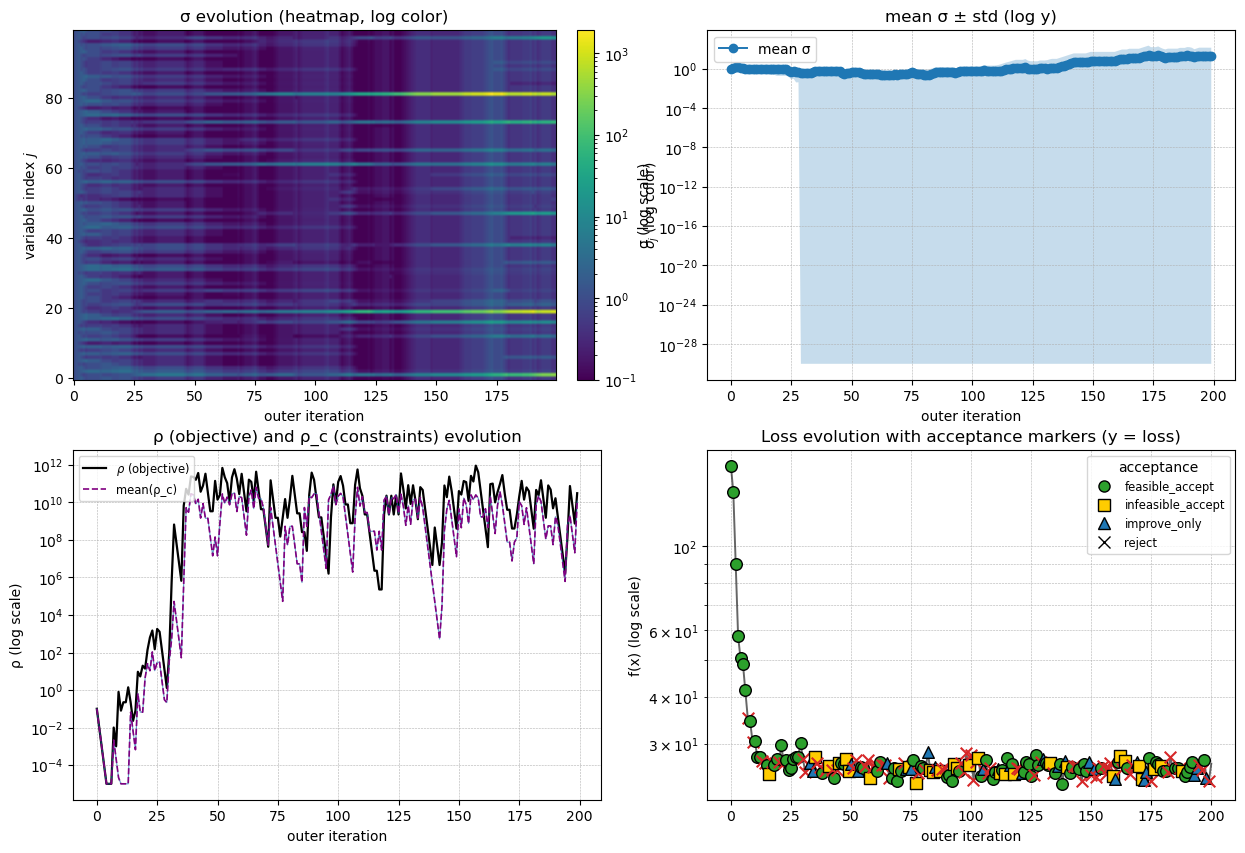

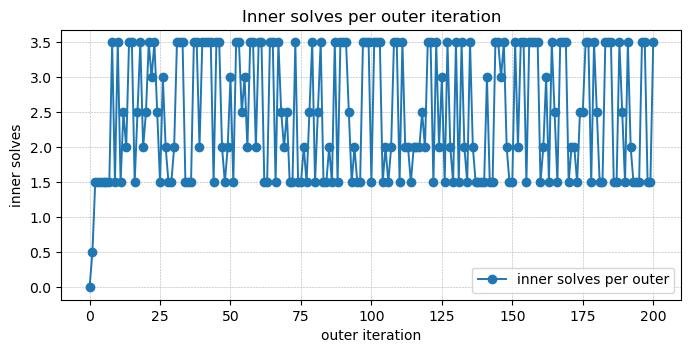


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 2.061e+01, final std = 1.178e+02
Rho (objective): final = 3.105e+10
Rho_c (constraints): shape = (200, 1), final mean = 1.166e+10

Acceptance counts:
Counter({'feasible_accept': 79, 'reject': 66, 'infeasible_accept': 30, 'improve_only': 25})

Average inner solves per outer step (observed): 2.45
CCSA σ=0.1: cumulative_wval=149.73, weighted_evals=493.5, x_history_len=201


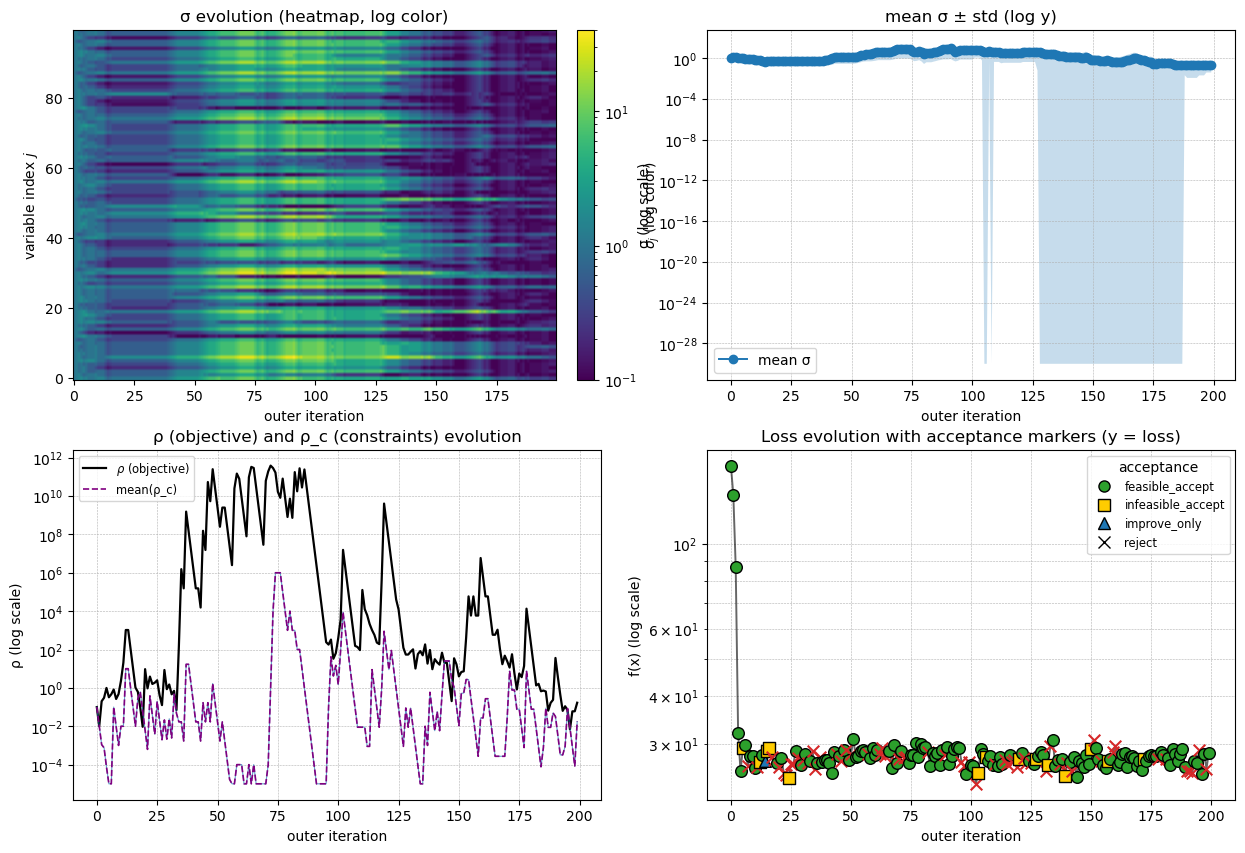

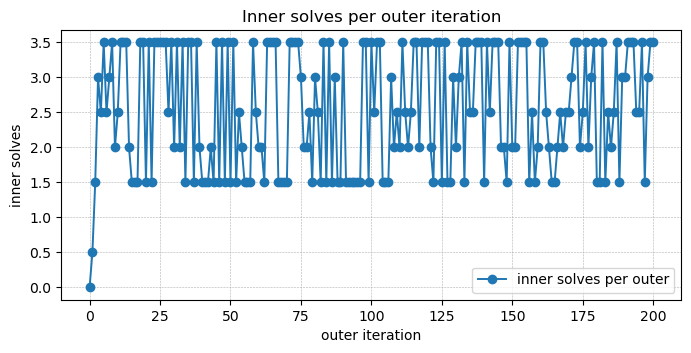


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 1.962e-01, final std = 1.568e-01
Rho (objective): final = 1.682e-01
Rho_c (constraints): shape = (200, 1), final mean = 1.764e-02

Acceptance counts:
Counter({'feasible_accept': 127, 'reject': 58, 'infeasible_accept': 14, 'improve_only': 1})

Average inner solves per outer step (observed): 2.54
CCSA σ=0.1: cumulative_wval=52.439, weighted_evals=512.5, x_history_len=201


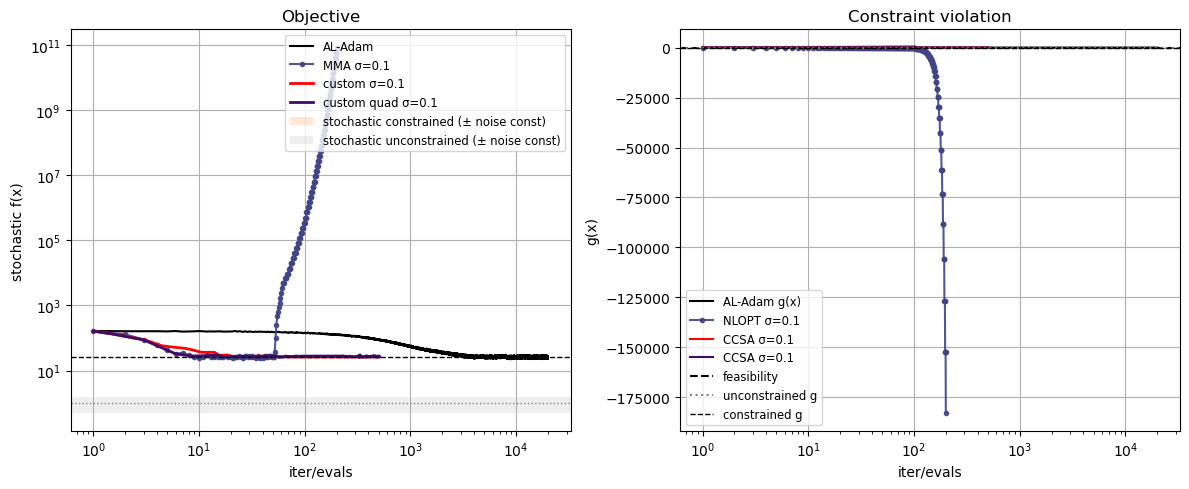

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
from ccsa_w_adaptation import MMAOptimizer, MMA_SigmaParams, MMA_RhoParams
import nlopt

import os, random

from experiments import stoch_convex_con_exp

seed = 2

active_constraint = True  
init_feasible = True

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# init point (local version using rng)
def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = rng.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

# random linear constraint
c = rng.randn(n)
c /= np.linalg.norm(c)
x_uncon = np.zeros(n)
if active_constraint is None:
    b = rng.uniform(-1, 1)
elif active_constraint:
    b = np.dot(c, x_uncon) - 5.0
else:
    b = np.dot(c, x_uncon) + 5.0

x0 = init_point_local(n, c, b, force_feasible=init_feasible)

sigma_min = 1e-1
n = 100
rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
sigma_params_run = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min, rel_min=0.01, rel_max=10.0)



ccsa_opt = MMAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy()               
        )

ccsa_quad = MMAOptimizer(
            params=x0.copy(),    # initial point
            fun=None,                # single-call oracle (value+grad from same xi)
            g=None,
            rho_params=rho_params,
            sigma_params=sigma_params_run,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,   # let MMAOptimizer request grad via fun(..., grad=True)
            x0=x0.copy(),
            use_quadratic_surrogates=True              
        )


opt = nlopt.opt(nlopt.LD_MMA, n)
opt.set_param("sigma_min", sigma_min)
opt.set_param("inner_maxeval", 5)


# Run experiments for the new implementation
for noise in [0.1]:
    for cond in [1]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        stoch_convex_con_exp(ccsa_opt, ccsa_quad, opt, c=c, b=b, x0=x0, noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True)

=== Running noise = 0.01, cond# = 1 ===
Random constraint: ||c||=1, b=-5
Analytic expected optimum (on expectation):
  active? True
  ||x*||=5, λ*=10
  E[f(x*)]=25.01 (noise const=0.01)
Unconstrained baseline: E[f(x_uncon)]= 0.01, g(x_uncon)=5
Initial constraint g(x0)=-0.993117 (init_feasible=True)

AL-Adam finished:
  last f_est=24.9663, g(x)=-0.00931219, λ=9.96851

nlopt σ=0.1: res=5, ||x||=5.02, g(x)=0.0209


/Users/antoniovaragnolo/Desktop/Research/CCSA/ccsa_mma_w_adaptation.py:790: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax3.scatter(i, f_hist[i], color=color, edgecolor='k', s=70, marker=marker, zorder=10)


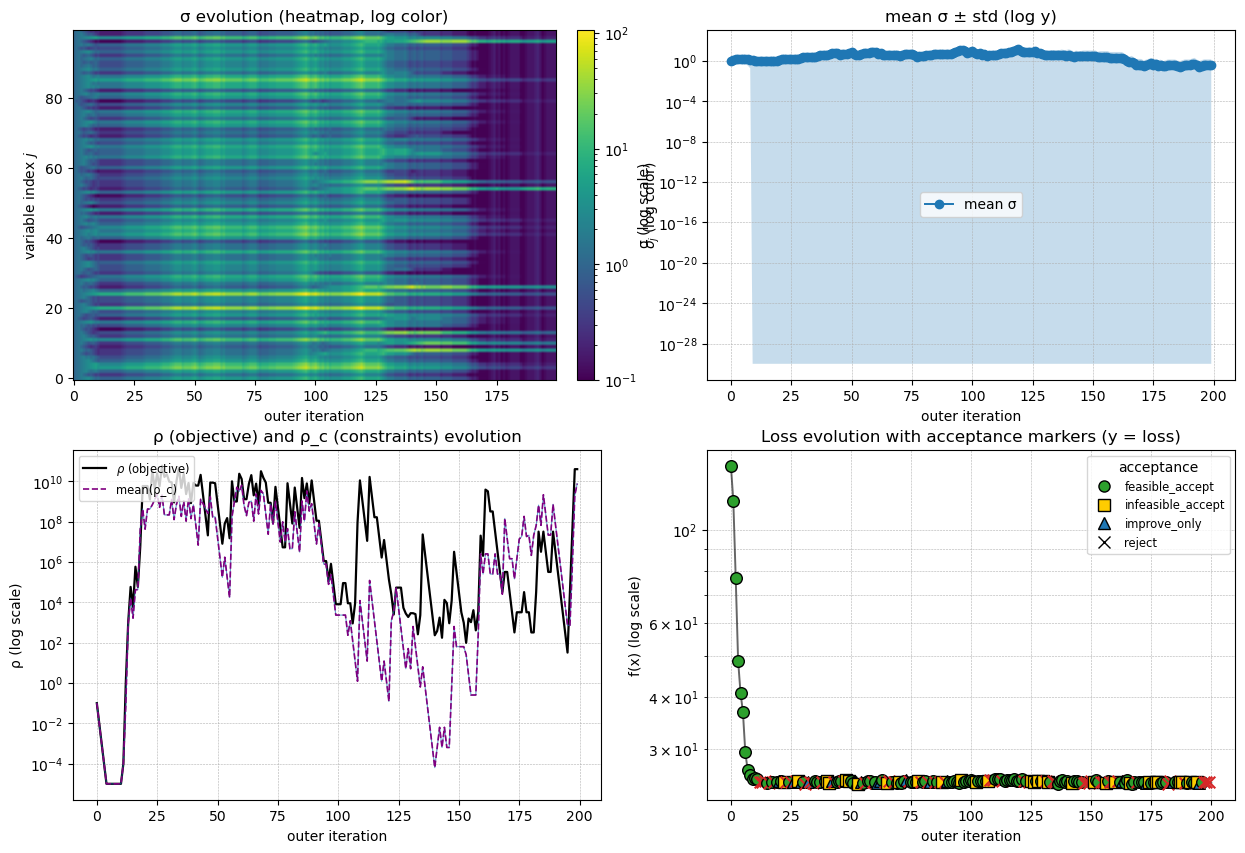

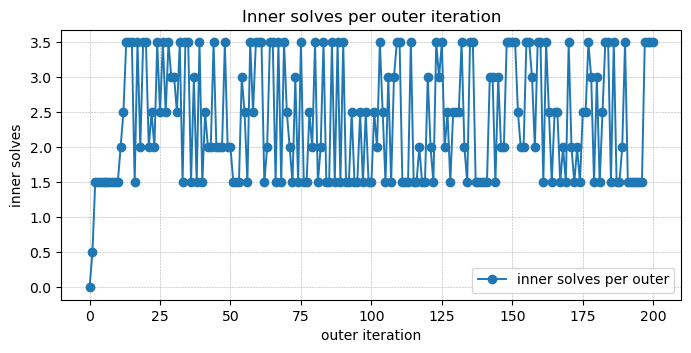


=== MMA Diagnostic Summary ===
Recorded outer iterations (f history): 201
Sigma: final mean = 3.682e-01, final std = 9.929e-01
Rho (objective): final = 4.027e+10
Rho_c (constraints): shape = (200, 1), final mean = 7.679e+09

Acceptance counts:
Counter({'feasible_accept': 104, 'reject': 49, 'infeasible_accept': 31, 'improve_only': 16})

Average inner solves per outer step (observed): 2.37
CCSA σ=0.1: cumulative_wval=92.526, weighted_evals=477.0, x_history_len=201


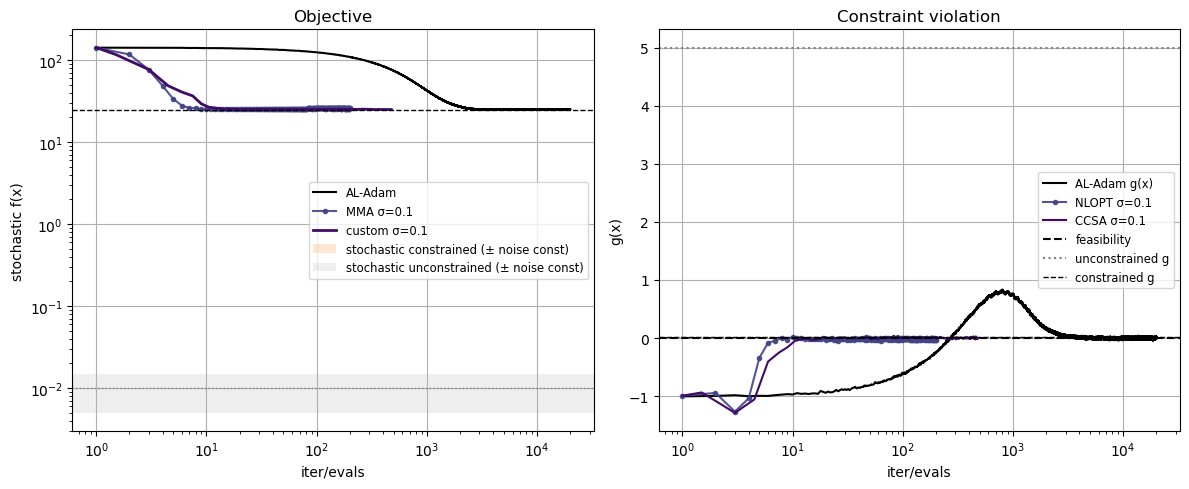

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from cssca.core import CSSCAOptimizer, RecursiveSurrogateConfig

from utils import randcond
from baselines.adam_al import adam_augmented_lagrangian

import os, random

seed = 0

np.random.seed(seed)

random.seed(seed)

rng = np.random.RandomState(seed)

torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # if using torch ops (may raise on non-deterministic ops)
# OpenMP / BLAS threading (see #3)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


# ---------------------------
# Helper: initialize x0 feasible or infeasible (kept as top-level but not used inside run)
# ---------------------------
def init_point(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
    x0 = np.random.randn(n)
    g0 = float(np.dot(c, x0) - b)
    if force_feasible:
        if g0 > 0:
            delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    else:
        if g0 <= 0:
            delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
            x0 = x0 + delta
    return x0

def run_convex_stoch_det_constraint_exp(
    noise: float = 0.2,
    cond: int = 1,
    sigma_mins: list = [0.0, 0.01, 0.1],
    seed: int = 0,
    maxiters_adam: int = 20000,
    mma_maxeval: int = 2000,
    active_constraint = True,
    init_feasible: bool = False,
    inner_kwargs = None,
    rho: float = 1.0,
    lambda0: float = 0.0,
    tol_outer: float = 1e-6,
    rho_multiplier: float = 2.0,
    rho_update_max: int = 6,
    max_outer = 8,
    verbose: bool = True,
    ccsa_plot_expected: bool = True,
    ccsa_n_outer: int = 100
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import nlopt

    # deterministic RNG for this experiment (single source)
    rng = np.random.RandomState(seed)

    n = 100
    A = np.eye(n) if cond == 1 else randcond(n, cond)
    A2 = A.T @ A
    traceA2 = float(np.trace(A2))

    # random linear constraint
    c = rng.randn(n)
    c /= np.linalg.norm(c)
    x_uncon = np.zeros(n)
    if active_constraint is None:
        b = rng.uniform(-1, 1)
    elif active_constraint:
        b = np.dot(c, x_uncon) - 5.0
    else:
        b = np.dot(c, x_uncon) + 5.0

    print(f"Random constraint: ||c||={np.linalg.norm(c):.6g}, b={b:.6g}")

    # analytic expected optimum
    def analytic_solution_expectation(A, c, b, noise):
        A2 = A.T @ A
        s = np.linalg.solve(A2, c)
        denom = float(c.dot(s))
        if b >= 0:
            x_star = np.zeros_like(c)
            lambda_star = 0.0
            active_flag = False
        else:
            x_star = (b / denom) * s
            lambda_star = -2.0 * b / denom
            active_flag = True
        const_term = (noise**2) * np.trace(A2)
        val = float(x_star.dot(A2.dot(x_star))) + const_term
        return x_star, lambda_star, active_flag, val, const_term

    x_star, lambda_star, active_flag, val_star, const_term = analytic_solution_expectation(A, c, b, noise)
    print("Analytic expected optimum (on expectation):")
    print(f"  active? {active_flag}")
    print(f"  ||x*||={np.linalg.norm(x_star):.6g}, λ*={lambda_star:.6g}")
    print(f"  E[f(x*)]={val_star:.6g} (noise const={const_term:.6g})")

    val_uncon = const_term
    g_uncon = -b
    print(f"Unconstrained baseline: E[f(x_uncon)]= {val_uncon:.6g}, g(x_uncon)={g_uncon:.6g}")

    # --- deterministic sampling closure used by all function/grad calls in this run ---
    def sample_xi():
        return rng.randn(n) * noise

    # stochastic helpers that use sample_xi (keeps value/grad consistent if caller uses same xi)
    def fgrad_stoch(x):
        # returns gradient only (draws a sample)
        xi = sample_xi()
        return 2.0 * (A.T @ A @ (x + xi))
        #return 2.0 * (A.T @ A @ (x))

    def f_stoch_estimate(x):
        xi = sample_xi()
        return float(np.linalg.norm(A.dot(x + xi))**2)
        #return float(np.linalg.norm(A.dot(x))**2)

    def expected_f(x):
        return float(np.linalg.norm(A.dot(x))**2 + (noise**2) * traceA2)

    def constraint_val(x):
        xi = sample_xi()
        return float(np.dot(c, x + xi) - b)

    # init point (local version using rng)
    def init_point_local(n: int, c: np.ndarray, b: float, force_feasible: bool = False) -> np.ndarray:
        x0 = rng.randn(n)
        g0 = float(np.dot(c, x0) - b)
        if force_feasible:
            if g0 > 0:
                delta = ((b - np.dot(c, x0)) - 1.0) * c / (np.dot(c, c))
                x0 = x0 + delta
        else:
            if g0 <= 0:
                delta = ((b - np.dot(c, x0)) + 1.0) * c / (np.dot(c, c))
                x0 = x0 + delta
        return x0

    x0 = init_point_local(n, c, b, force_feasible=init_feasible)
    print(f"Initial constraint g(x0)={constraint_val(x0):.6g} (init_feasible={init_feasible})")
    print()

    

    x_al, lam_al, hist_al = adam_augmented_lagrangian(
        fgrad=fgrad_stoch,                 # stochastic gradient of the objective
        x0=x0.copy(),                      # initial point
        g=constraint_val,                  # stochastic constraint evaluator g(x)
        dg=lambda xx: c,                   # analytic gradient of g w.r.t x (here it's constant c)
        rho=rho,                           # initial AL penalty
        lambda0=lambda0,                   # initial Lagrange multiplier
        f_stoch_estimate=f_stoch_estimate, # optional stochastic function estimate for logging
        alpha=1e-3,
        maxiters=maxiters_adam,
        tol=tol_outer,
        rho_multiplier=rho_multiplier,
        rho_update_max=rho_update_max,
        max_outer=max_outer,
        verbose=verbose)


    print("AL-Adam finished:")
    last_f_est = hist_al['f_est'][-1] if len(hist_al['f_est'])>0 else np.nan
    last_g = hist_al['g'][-1] if len(hist_al['g'])>0 else constraint_val(x_al)
    print(f"  last f_est={last_f_est:.6g}, g(x)={last_g:.6g}, λ={lam_al:.6g}")
    print()

    # NLopt-MMA (unchanged except it now uses sample_xi from same rng)
    mma_results = []
    colors_mma = plt.cm.viridis(np.linspace(0.2, 0.8, len(sigma_mins)))
    for sigma_min, color in zip(sigma_mins, colors_mma):
        opt = nlopt.opt(nlopt.LD_MMA, n)
        evals = 0.0
        mma_f_evals, mma_g_vals, mma_f_vals = [], [], []
        def f_and_grad_mma(x, grad):
            nonlocal evals, mma_f_evals, mma_g_vals, mma_f_vals
            xi = sample_xi()       # same RNG sequence
            p = A.dot(x + xi)
            val = float(np.linalg.norm(p)**2)
            if grad.size > 0:
                grad[:] = 2.0 * (A.T.dot(p))
                evals += 1
                mma_f_evals.append(evals)
                mma_f_vals.append(val)
                mma_g_vals.append(constraint_val(x))
            else:
                evals += 0.5
            return val
        def cons_nl(x, grad):
            xi = sample_xi()   # same RNG sequence
            if grad.size > 0: grad[:] = c
            return float(c.dot(x + xi) - b)
        opt.add_inequality_constraint(cons_nl, 0.0)
        opt.set_min_objective(f_and_grad_mma)
        opt.set_maxeval(mma_maxeval)
        opt.set_param("rho_init", 1.0)
        opt.set_param("sigma_min", float(sigma_min))
        x_mma = opt.optimize(x0.copy())
        res_code = opt.last_optimize_result()
        print(f"nlopt σ={sigma_min}: res={res_code}, ||x||={np.linalg.norm(x_mma):.3g}, g(x)={constraint_val(x_mma):.3g}")
        mma_results.append((sigma_min, color, mma_f_evals, mma_g_vals, mma_f_vals))

    # --- single-call noisy oracle: value+grad use the same sample (like NLopt f_and_grad) ---
    def make_noisy_f_and_grad(A, sample_xi):
        def f_and_grad(x, grad=None):
            xi = sample_xi()           # single random sample
            p = A.dot(x+ xi)
            val = float(np.linalg.norm(p)**2)
            grad_val = 2.0 * (A.T.dot(p))
            
            # If grad=True (like MMAOptimizer uses)
            if grad is True:
                return val, grad_val
            
            # If grad is an array (like NLopt interface)
            if isinstance(grad, np.ndarray):
                grad[:] = grad_val
                return val
            
            # Otherwise, only return value
            return val
        return f_and_grad
    
    rho_params = MMA_RhoParams(softening=0.5, min_growth=1.01, max_multiplier=10.0, decay=0.1)
    sigma_params = MMA_SigmaParams(expand=1.2, contract=0.7, sigma_min=sigma_min,  rel_min=0.01, rel_max=10.0)


    # CCSA custom runs (separate distinct colors)
    colors_ccsa = plt.cm.inferno(np.linspace(0.2, 0.8, len(sigma_mins)))
    ccsa_results = []
    for sigma_min, color in zip(sigma_mins, colors_ccsa):
        # build a single-call oracle that uses the same sample_xi as the NLopt block above
        oracle = make_noisy_f_and_grad(A, sample_xi)

        ccsa_opt = MMAOptimizer(
            params=x0.copy(),
            fun=oracle,                # single-call oracle (value+grad from same xi)
            g=constraint_val,
            rho_params=rho_params,
            sigma_params=sigma_params,
            bounds=None,
            rho_init=1.0,
            max_inner=5,
            df=None,                   # let MMAOptimizer request grad via fun(..., grad=True)
            dg=lambda xx: np.atleast_2d(c),
            x0=x0.copy()
        )

        metrics = None
        f_b = None
        all_x = []

        for out in range(mma_maxeval):
            f_b, g_b, metrics = ccsa_opt.step()
            all_x.append(metrics["x_history"][-1])
        
        ccsa_opt.summarize_diagnostics()

        #ccsa_opt.summarize_diagnostics()
        x_hist = np.asarray(metrics.get("x_history", []))
        cum_we_hist = np.asarray(metrics.get("cumulative_weighted_evals_history", []), dtype=float)
        if x_hist.ndim == 1 and x_hist.size>0:
            x_hist = x_hist.reshape((1, -1))
        if x_hist.shape[0] > 0:
            f_expected_at_xhist = [expected_f(xi) for xi in x_hist]
            f_stoch_at_xhist = [f_stoch_estimate(xi) for xi in x_hist]
            g_at_xhist = [constraint_val(xi) for xi in x_hist]
        else:
            f_expected_at_xhist = []
            f_stoch_at_xhist = []
            g_at_xhist = []
        if cum_we_hist.size == 0:
            cum_we_hist = np.arange(1, len(f_expected_at_xhist)+1, dtype=float)
        ccsa_results.append({
            "sigma_min": sigma_min,
            "color": color,
            "metrics": metrics,
            "x_hist": x_hist,
            "cum_we_hist": cum_we_hist,
            "f_expected_at_xhist": np.array(f_expected_at_xhist),
            "f_stoch_at_xhist": np.array(f_stoch_at_xhist),
            "g_at_xhist": np.array(g_at_xhist)
        })
        print(f"CCSA σ={sigma_min}: cumulative_wval={metrics.get('cumulative_wval', np.nan):.6g}, weighted_evals={metrics.get('weighted_evals', np.nan)}, x_history_len={len(x_hist)}")
    

    
   

    # Plotting: objective + constraint panels with patches
    plt.figure(figsize=(12,5))

    # define patch half-height based on noise const (visualization choice)
    patch_half = max(1e-12, 0.5 * (noise**2) * traceA2)

    # objective panel
    ax1 = plt.subplot(1,2,1)
    ax1.plot(hist_al['iter'], hist_al['f_est'], '-', color='black', label='AL-Adam')

    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        ax1.plot(f_evals, f_vals, '.-', color=color, alpha=0.9, label=f'MMA σ={sigma_min}')

    # CCSA: solid lines, different color palette (not dashed)
    for cr in ccsa_results:
        if ccsa_plot_expected:
            ax1.plot(cr['cum_we_hist'], cr['f_expected_at_xhist'], linestyle='-', linewidth=2.0,
                     color=cr['color'], label=f'custom σ={cr["sigma_min"]}')
        else:
            ax1.plot(cr['cum_we_hist'], cr['f_stoch_at_xhist'], linestyle='-', linewidth=1.5,
                     marker='.', color=cr['color'], label=f'custom σ={cr["sigma_min"]}')

    # shaded patches for stochastic constrained and unconstrained (horizontal bands)
    # constrained: center at val_star
    ax1.axhspan(val_star - patch_half, val_star + patch_half, alpha=0.18, facecolor='tab:orange')
    # unconstrained baseline: center at val_uncon
    ax1.axhspan(val_uncon - patch_half, val_uncon + patch_half, alpha=0.12, facecolor='tab:gray')
    ax1.plot()


    # add legend patches for these bands
    constrained_patch = mpatches.Patch(facecolor='tab:orange', alpha=0.18, label='stochastic constrained (± noise const)')
    unconstrained_patch = mpatches.Patch(facecolor='tab:gray', alpha=0.12, label='stochastic unconstrained (± noise const)')
    # build legend (include patches)
    handles, labels = ax1.get_legend_handles_labels()
    handles = handles + [constrained_patch, unconstrained_patch]
    labels = labels + [constrained_patch.get_label(), unconstrained_patch.get_label()]
    ax1.legend(handles, labels, loc='best', fontsize='small')

    ax1.axhline(val_star, color='k', linestyle='--', linewidth=1.0)
    ax1.axhline(val_uncon, color='gray', linestyle=':', linewidth=1.0)
    ax1.set_xscale('log'); ax1.set_yscale('log')
    ax1.grid(True); ax1.set_xlabel('iter/evals'); ax1.set_ylabel('stochastic f(x)'); ax1.set_title('Objective')

    # constraint panel
    ax2 = plt.subplot(1,2,2)
    ax2.plot(hist_al['iter'], hist_al['g'], '-', color='black', label='AL-Adam g(x)')
    for sigma_min, color, f_evals, g_vals, f_vals in mma_results:
        ax2.plot(f_evals, g_vals, '.-', color=color, alpha=0.9, label=f'NLOPT σ={sigma_min}')
    for cr in ccsa_results:
        ax2.plot(cr['cum_we_hist'], cr['g_at_xhist'], linestyle='-', color=cr['color'], label=f'CCSA σ={cr["sigma_min"]}')
    
    
    ax2.axhline(0, color='k', linestyle='--', label='feasibility')
    ax2.axhline(g_uncon, color='gray', linestyle=':', label='unconstrained g')
    ax2.axhline(constraint_val(x_star), color='k', linestyle='--', linewidth=1.0, label='constrained g')
    ax2.set_xscale('log'); ax2.grid(True); ax2.set_xlabel('iter/evals'); ax2.set_ylabel('g(x)'); ax2.set_title('Constraint violation')
    ax2.legend(loc='best', fontsize='small')

    plt.tight_layout()
    plt.savefig("convex_stoch_det_constraint_experiment.png", dpi=300)
    plt.show()

    # --- Plot σ evolution for first 3 parameters ---
    sig_hist = np.array(metrics["sigma_history"])  # shape (iters, n)
    rho_hist = np.array(metrics["rho_history"])    # shape (iters,)

    return {
        "c": c, "b": b,
        "x_star": x_star, "val_star": val_star,
        "x_al": x_al, "lam_al": lam_al,
        "mma_results": mma_results,
        "ccsa_results": ccsa_results,
        "val_uncon": val_uncon, "g_uncon": g_uncon,
        "hist_al": hist_al
    }



for noise in [0.01]:
    for cond in [1]:
        print(f"=== Running noise = {noise}, cond# = {cond} ===")
        run_convex_stoch_det_constraint_exp(noise=noise, cond=cond, seed=seed, sigma_mins=[1e-1], maxiters_adam = 20000,
    mma_maxeval = 200,
    active_constraint = True,
    init_feasible =True)



If we make the constraint stochastic then there is an issue related to the respect of this constraint. MMA fails because of it